In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [3]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
    #setParametersALN(aln)
                    
def setParametersALN(model):
    model.params.rates_exc_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.rates_inh_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mufe_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.mufi_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.IA_init = np.array( [[0. * 200. * 0.5 ]] )  # pA
    model.params.seem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.seim_init = np.array( [[0. * 0.5 * 0.5 ]] )   
    model.params.seev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.seiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siim_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mue_ou = np.array( [[0. * 0.4]] ) #* np.ones((model.params.N,))
    model.params.mui_ou = np.array( [[0. * 0.3]] ) #* np.ones((model.params.N,))           

In [4]:
tol = 1e-32

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

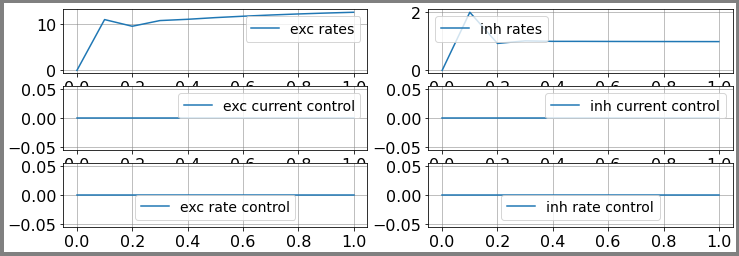

In [47]:
aln = RateModel()

aln.params['duration'] = 1.
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

aln.params.cie = 1.
aln.params.Jie_max = 1.
aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

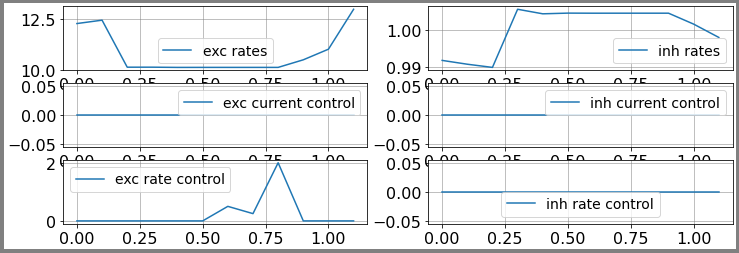

no delay : 
exc rates :  [12.28807506 12.45521094 10.12963071 10.13024102 10.11911909 10.11998748
 10.11985593 10.11987117 10.11986922 10.49486946 11.01986943 12.99446001]
inh rates :  [0.9918678  0.99084309 0.98998814 1.00558437 1.0043654  1.00455004
 1.00452866 1.00453139 1.00453105 1.00453109 1.00159731 0.99802572]


In [52]:
dur = 0.8
dur_pre = 0.3
dur_post = 0.3

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

aln.params.duration = dur + dur_pre

control_ind = [2]
prec_var = [0]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 5.
    min_cntrl = -5.
else:
    max_cntrl = 5.#0.5
    min_cntrl = -5.# 0.5

control0 = aln.getZeroControl()

for j in control_ind:
    #control0[0,j,n_pre + 0] = 1.0 * max_cntrl - 0.0 * min_cntrl
    #control0[0,j,n_pre + 1] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 2] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 3] = 0.05 * max_cntrl #- 0.0 * min_cntrl
    control0[0,j,n_pre + 4] = 0.2 * max_cntrl - 0.2 * min_cntrl
    #control0[0,j,n_pre + 5] = 0.5 * max_cntrl - 0.6 * min_cntrl
    #control0[0,j,n_pre + 6] = 1.0 * max_cntrl - 0.8 * min_cntrl

#control0[0,1,:] = 0.    

setinitvars(high_state_vars)

plotFunc.plot_traces(aln, control0)
print("no delay : ")
print("exc rates : ", aln.rates_exc[0,:])
print("inh rates : ", aln.rates_inh[0,:])

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,n_pre-1:]
target[0,1,:] = aln.rates_inh[0,n_pre-1:]

control1 = aln.getZeroControl()
for k in range(1, control1.shape[2]-1):
    control1[0,j,k] += random.uniform(0., 1.) * 0.1 * max_cntrl

In [53]:
costparams = [1. * 1e0, 0.* 1e-0, 0.* 1e-0]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 1000
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
#control1 = aln.getZeroControl()
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
control3 = control0[:,:,n_pre-1:]
control3[0,2,:] *= 0.999
control5 = bestControlA_A2[:,:,n_pre-1:-n_post+1]

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control3, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 3.810394756896814

set cost params
RUN  0 , total integrated cost =  4.606753321056558e-07
RUN  1 , total integrated cost =  1.290571623925941e-07
RUN  2 , total integrated cost =  3.3263820384759325e-08
RUN  3 , total integrated cost =  2.6388963848900467e-08
RUN  4 , total integrated cost =  1.6199802318724452e-08
RUN  5 , total integrated cost =  1.4415671529105656e-08
RUN  6 , total integrated cost =  1.2958851999628691e-08
RUN  7 , total integrated cost =  1.1864546883418707e-08
RUN  8 , total integrated cost =  1.1226890809247297e-08
RUN  9 , total integrated cost =  1.0765035339155955e-08
RUN  10 , total integrated cost =  1.0081031860082985e-08
RUN  11 , total integrated cost =  9.530578842475057e-09
RUN  12 , total integrated cost =  9.236437286679424e-09
RUN  13 , total integrated cost =  8.938207786453125e-09
RUN  14 , total integrated cost =  8.538018466334157e-09
RUN  15 , total integrated cost =  8.169183909054224e-09
RUN  16 , total integrated cost =  7.930143317652673e-09
RUN  17 , total 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  6.721323519957703e-11
RUN  1000 , total integrated cost =  6.721323519957703e-11
Improved over  1000  iterations by  99.98540984712761  percent.
Problem in initial value trasfer:  sigmae_f 1.8436860676628468 10.119119090378874
Problem in initial value trasfer:  sigmae_f 1.8122872095741922 10.12450634890882
control ind  2
grad =  [ 4.06486449e-06  3.65826607e-06  3.28559987e-06 -1.46520621e-06
  6.53102929e-06 -4.85197375e-06  0.00000000e+00  0.00000000e+00
  0.00000000e+00]
best control =  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.54233220e-07
 -6.84617447e-06  3.37532894e-05  4.99921601e-01  2.50108064e-01
  1.99990966e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00]
total runtime =  13.880489500001204


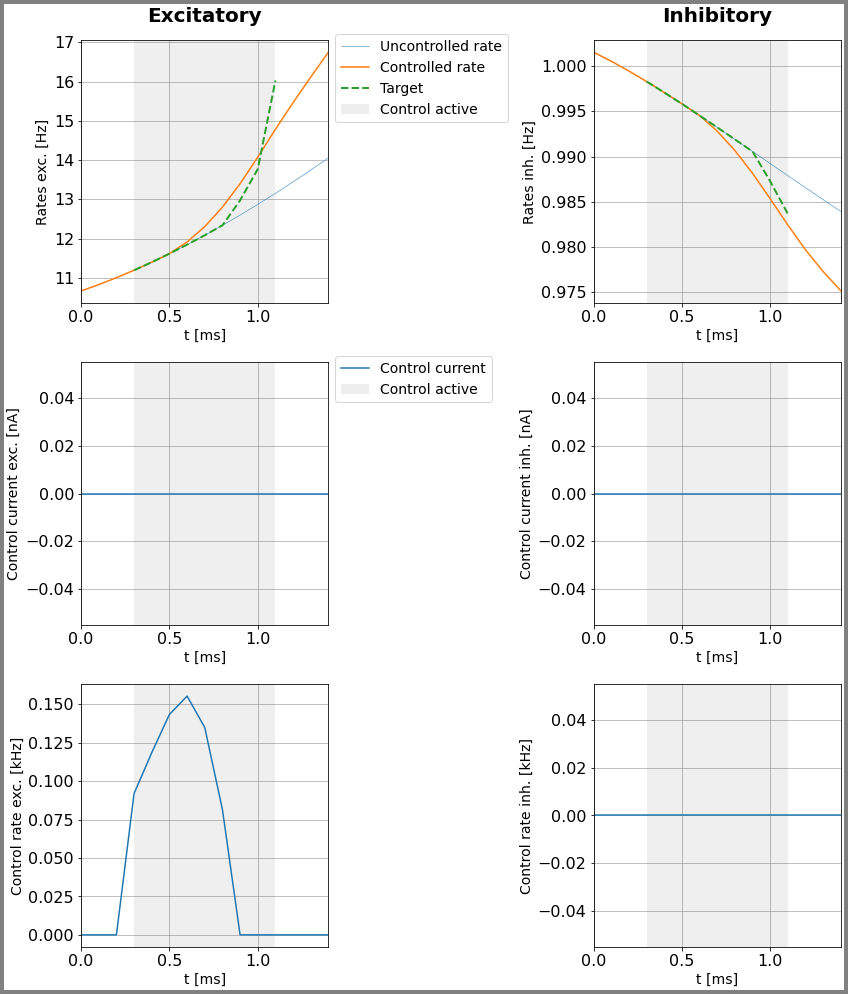

In [45]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

In [46]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 10
start_step = 0.1
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-12

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA[:,:,n_pre-1:-n_post+1] #* random.uniform(0.001,0.002)

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control4, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

for i in range(1, len(costA_A2)):
    if costA_A2[i-1] < costA_A2[i]:
        print("ERROR ---------------- in index ", i)
        
print(bestControlA_A2[0,control_ind[0], :])

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
RUN  0 , total integrated cost:  0.20472582352031743
Control only changes marginally.
RUN  1 , total integrated cost:  0.20472582352031743
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.8318346037579103 10.124310662661783
Problem in initial value trasfer:  sigmae_f 1.7940320189284416 10.1356425954291
[0.00000000e+00 0.00000000e+00 0.00000000e+00 9.19572139e-02
 1.18519583e-01 1.43385651e-01 1.55307153e-01 1.34895938e-01
 8.15302436e-02 7.79635310e-11 9.83666985e-11 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]


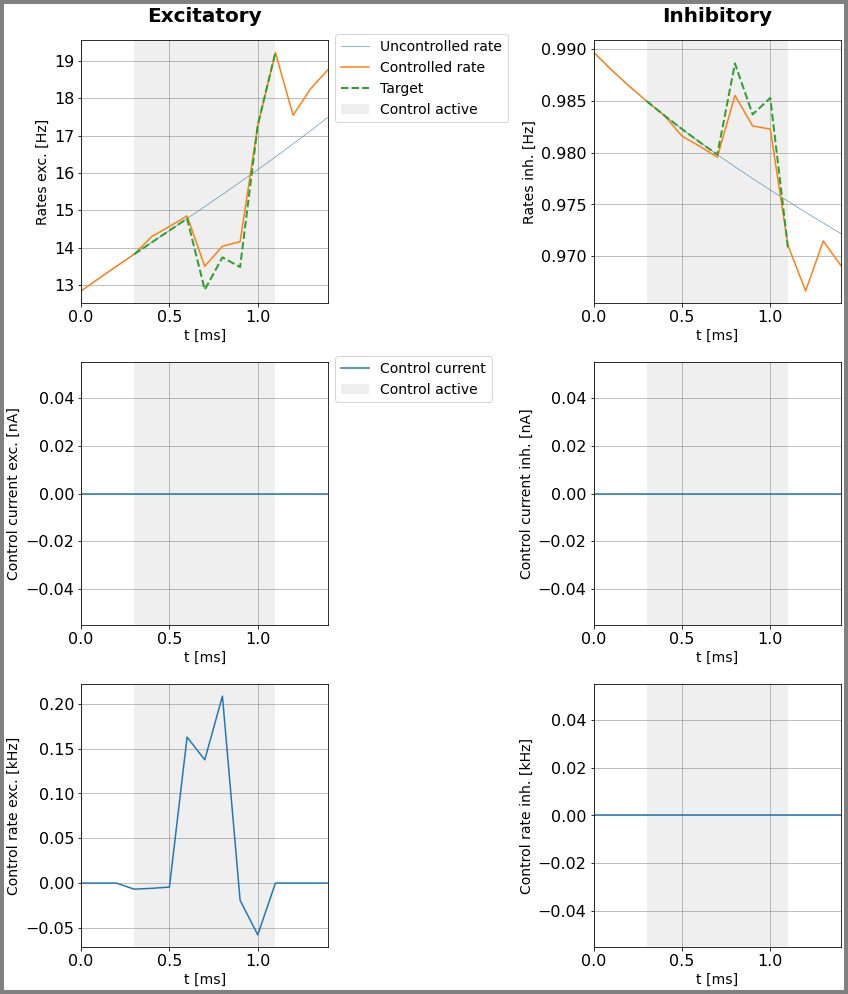

In [32]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

### Test cases

- [] precision only, c0-p0, no delay
- [] precision only, c0-p0, delay
- [] precision only, c0-p1, no delay
- [] precision only, c0-p1, delay
- [] precision only, c1-p1, no delay
- [] precision only, c1-p1, delay
- [] precision only, c1-p0, no delay
- [] precision only, c1-p0, delay
- [] precision only, c2-p0, no delay
- [] precision only, c2-p0, no delay
- [] precision only, c2-p1, delay
- [] precision only, c2-p1, delay

- [] p+e+s, c0-p0, no delay
- [] p+e+s, c0-p0, delay
- [] p+e+s, c0-p1, no delay
- [] p+e+s, c0-p1, delay
- [] p+e+s, c1-p1, no delay
- [] p+e+s, c1-p1, delay
- [] p+e+s, c1-p0, no delay
- [] p+e+s, c1-p0, delay
- [] p+e+s, c2-p0, no delay
- [] p+e+s, c2-p0, no delay
- [] p+e+s, c2-p1, delay
- [] p+e+s, c2-p1, delay

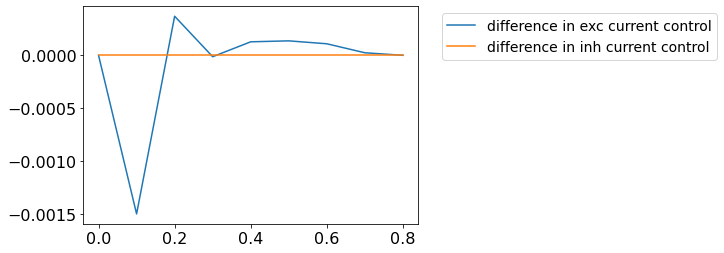

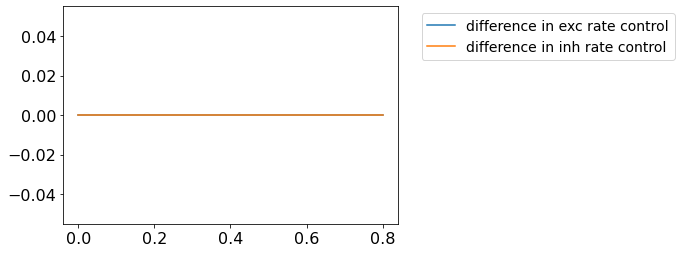

In [114]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.